# Lexical dispersion

In [7]:
import polars as pl
import polars_corpus as plc

import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_float_precision(3)
pl.Config.set_thousands_separator(",")

In [8]:
amalgum = pl.read_parquet("../../data/amalgum.parquet")

- `range` : number of files the word occurs in
- `range%` : the range as a percentage of the files in the corpus
- `sd` : standard deviation of the per-file frequencies $Y_i$:
  $$S=\sqrt{\frac{1}{k}\sum_{i=1}^k(Y_i-\bar Y)^2}$$
- `cv` : coefficient of variation, sd over the mean
   $$CV=\frac{S}{\bar Y}$$
- `cv%` : the coefficient of variation as a percentage
   $$CV\%=\frac{CV}{\sqrt{\textrm{no.\ of corpus parts}}}$$
- `d` : Julliand's $D$:
  $$D=1-\sqrt{\frac{\frac{1}{k-1}\sum_{i=1}^k(Y_i-\bar Y)^2}{k\bar Y^2}}$$
  $$D=1-\sqrt{\frac{\frac{1}{k-1}\sum_i=1^k(Y_i-\bar Y)^2}{k\bar Y^2}$$

- `da` : Burch's $D_A$, from the average difference between pairs of files
- `dp` : Gries's $D_P$, how far the word's spread over the files falls from the corpus's own

In [9]:
disp = plc.dispersion(
    amalgum,
    "token",
    method=["range", "range%", "sd", "cv", "cv%", "d", "da", "dp"],
    min_freq=200,
)

In [10]:
disp.sort(by="DA", descending=True).head(10)

token,freq,range,range%,sd,cv,cv%,D,DA,DP
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
""".""","165,368","4,682",100.000,0.013,0.307,30.654,0.996,0.837,0.117
""",""","192,424","4,679",99.936,0.017,0.349,34.888,0.995,0.810,0.132
"""and""","95,116","4,680",99.957,0.009,0.368,36.836,0.995,0.795,0.143
"""the""","182,501","4,682",100.000,0.018,0.377,37.745,0.994,0.790,0.145
"""to""","84,596","4,676",99.872,0.009,0.406,40.580,0.994,0.772,0.160
"""a""","67,458","4,679",99.936,0.008,0.437,43.659,0.994,0.761,0.165
"""in""","63,088","4,680",99.957,0.008,0.466,46.582,0.993,0.745,0.177
"""of""","100,394","4,682",100.000,0.012,0.461,46.055,0.993,0.745,0.181
"""for""","27,966","4,568",97.565,0.004,0.605,60.549,0.991,0.669,0.229


In [11]:
disp.sort(by="DA", descending=False).head(10)

token,freq,range,range%,sd,cv,cv%,D,DA,DP
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""Pasha""",248,21,0.449,0.001,21.868,"2,186.771",0.680,0.002,0.994
"""Brian""",224,38,0.812,0.001,24.237,"2,423.728",0.646,0.002,0.992
"""que""",240,31,0.662,0.001,17.124,"1,712.435",0.750,0.003,0.994
"""Nicholas""",264,62,1.324,0.001,21.742,"2,174.217",0.682,0.004,0.985
"""¥""",252,30,0.641,0.001,14.724,"1,472.442",0.785,0.004,0.991
"""Khan""",394,62,1.324,0.002,16.644,"1,664.429",0.757,0.004,0.986
"""pet""",386,60,1.282,0.002,14.536,"1,453.583",0.788,0.005,0.986
"""Trump""",248,41,0.876,0.001,13.599,"1,359.940",0.801,0.005,0.992
"""apartment""",215,72,1.538,0.001,14.734,"1,473.362",0.785,0.006,0.983


<Axes: xlabel='DA', ylabel='D'>

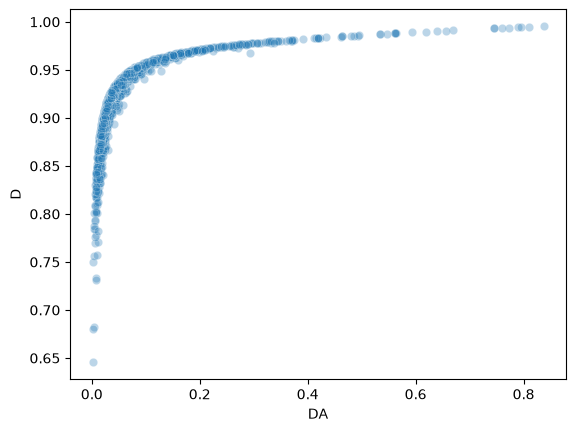

In [14]:
sns.scatterplot(disp, x="DA", y="D", alpha=0.3)

<Axes: xlabel='DA', ylabel='DP'>

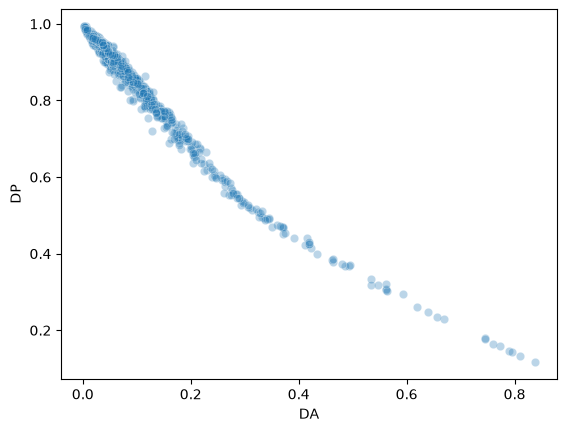

In [15]:
sns.scatterplot(disp, x="DA", y="DP", alpha=0.3)

In [16]:
disp.filter(pl.col("freq") == 200)

token,freq,range,range%,sd,cv,cv%,D,DA,DP
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""stores""",200,138,2.947,0.000,7.880,788.042,0.885,0.019,0.965
"""i""",200,96,2.050,0.001,12.034,"1,203.419",0.824,0.012,0.977
"""college""",200,130,2.777,0.000,7.322,732.194,0.893,0.018,0.971
"""device""",200,81,1.730,0.001,11.144,"1,114.378",0.837,0.009,0.983
"""Kingdom""",200,151,3.225,0.000,6.622,662.206,0.903,0.023,0.963
"""B""",200,95,2.029,0.000,8.837,883.667,0.871,0.012,0.977


<Axes: xlabel='index'>

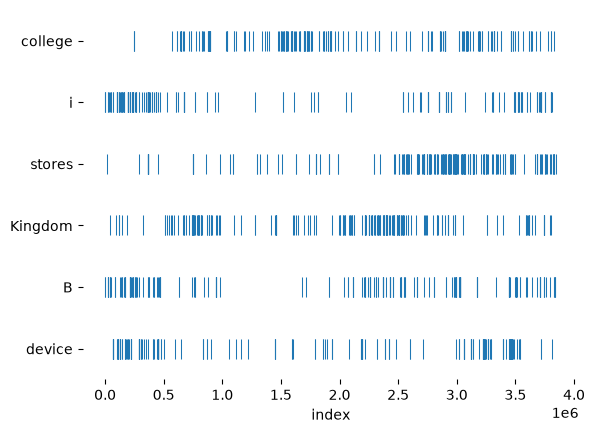

In [17]:
plc.barcode_plot(amalgum, "token", ["college", "i", "stores", "Kingdom", "B", "device"])

[]

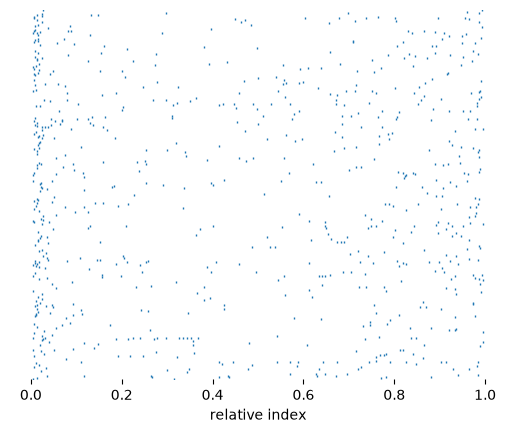

In [22]:
fig = plc.dispersion_plot(
    amalgum.filter(pl.col("text_type") == "bio"),
    "lemma",
    "die",
    relative=True,
    size=3,
    linewidth=1,
)
fig.set_yticks([])